In [2]:
import numpy as np
import cv2
import glob
from sklearn import svm
from sklearn.preprocessing import LabelEncoder


############################################################
#
#              Support Vector Machine
#              Image Classification
#
############################################################

def create_keypoints(w, h, step=15):
    keypoints = []
    keypointSize = 21
    for y in range(step, h - step, step):
        for x in range(step, w - step, step):
            keypoints.append(cv2.KeyPoint(float(x), float(y), keypointSize))
    return keypoints

# 1. Implement a SIFT feature extraction for a set of training images ./images/db/train/** (see 2.3 image retrieval)
# use ~15x15 keypoints on each image with subwindow of 21px (diameter)

TARGET_W, TARGET_H = 256, 256
sift = cv2.SIFT_create()
keypoints = create_keypoints(TARGET_W, TARGET_H, step=16)

images = glob.glob('./images/db/train/*/*.jpg')
descriptors = []

for image_path in images:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (TARGET_W, TARGET_H)) 
    _, des = sift.compute(img, keypoints)
    descriptors.append((des, image_path))

# 2. each descriptor (set of features) need to be flattened in one vector
# That means you need a X_train matrix containing a shape of (num_train_images, num_keypoints*num_entry_per_keypoint)
# num_entry_per_keypoint = histogram orientations as talked about in class
# You also need a y_train vector containing the labels encoded as integers

X_train = []
label_list = []

# Prepare expected descriptor length (SIFT: 128 per keypoint)
num_keypoints = len(keypoints)
descriptor_size = 128
expected_len = num_keypoints * descriptor_size

for des, image_path in descriptors:
    if des is None:
        vec = np.zeros(expected_len, dtype=np.float32)
    else:
        # ensure we have exactly num_keypoints rows; pad or truncate if needed
        if des.shape[0] != num_keypoints:
            padded = np.zeros((num_keypoints, descriptor_size), dtype=des.dtype)
            rows = min(des.shape[0], num_keypoints)
            padded[:rows, :] = des[:rows, :]
            vec = padded.flatten().astype(np.float32)
        else:
            vec = des.flatten().astype(np.float32)
    X_train.append(vec)
    label = image_path.split('/')[-2]
    label_list.append(label)

X_train = np.vstack(X_train)

# Encode string labels to integers
le = LabelEncoder()
y_train = le.fit_transform(label_list).astype(np.int32)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Classes:", list(le.classes_))


# 3. We use scikit-learn to train a SVM classifier - however you need to test with different kernel options to get
# good results for our dataset.

classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, y_train)


# 4. We test on a variety of test images ./images/db/test/ by extracting an image descriptor
# the same way we did for the training (except for a single image now) and use .predict()
# to classify the image

test_images = glob.glob('./images/db/test/*.jpg')
print(f"Found {len(test_images)} test images: {test_images}")
for test_image_path in test_images:
    img = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (TARGET_W, TARGET_H)) 
    _, des = sift.compute(img, keypoints)

    if des is None:
        test_vec = np.zeros(expected_len, dtype=np.float32)
    else:
        if des.shape[0] != num_keypoints:
            padded = np.zeros((num_keypoints, descriptor_size), dtype=des.dtype)
            rows = min(des.shape[0], num_keypoints)
            padded[:rows, :] = des[:rows, :]
            test_vec = padded.flatten().astype(np.float32)
        else:
            test_vec = des.flatten().astype(np.float32)

    des_flattened = test_vec.reshape(1, -1)
    predicted_label = classifier.predict(des_flattened)

    # 5. output the class + corresponding name
    predicted_name = le.inverse_transform(predicted_label)
    print(f"Test Image: {test_image_path}, Predicted Class: {predicted_label[0]} ({predicted_name[0]})")

X_train shape: (20, 25088)
y_train shape: (20,)
Classes: [np.str_('cars'), np.str_('faces'), np.str_('flowers')]
Found 4 test images: ['./images/db/test/flower2.jpg', './images/db/test/face.jpg', './images/db/test/car.jpg', './images/db/test/flower.jpg']
Test Image: ./images/db/test/flower2.jpg, Predicted Class: 2 (flowers)
Test Image: ./images/db/test/face.jpg, Predicted Class: 1 (faces)
Test Image: ./images/db/test/car.jpg, Predicted Class: 0 (cars)
Test Image: ./images/db/test/flower.jpg, Predicted Class: 2 (flowers)


0 ./images/db/train/cars/2539497709_756f025f62.jpg
0 ./images/db/train/cars/2847324790_6dd07ffb54.jpg
0 ./images/db/train/cars/1137646735_2fb2752249.jpg
0 ./images/db/train/cars/car001.jpg
0 ./images/db/train/cars/car003.jpg
0 ./images/db/train/cars/car002.jpg
1 ./images/db/train/flowers/astra04.jpg
1 ./images/db/train/flowers/3826419553_c00dc0e91c.jpg
1 ./images/db/train/flowers/2682530432_e470494b40.jpg
1 ./images/db/train/flowers/0106476_1.jpg
1 ./images/db/train/flowers/marcinki.jpg
1 ./images/db/train/flowers/ANBL.jpg
2 ./images/db/train/faces/3573927657_df093bae27.jpg
2 ./images/db/train/faces/397642272_cedf622248_z.jpg
2 ./images/db/train/faces/61060671.jpg
2 ./images/db/train/faces/face.jpg
2 ./images/db/train/faces/img_1577_crazy-face.jpg
2 ./images/db/train/faces/face2.jpg
2 ./images/db/train/faces/images.jpg
2 ./images/db/train/faces/3775982780_d5ea306ce6.jpg
iteration 0: loss 1.243592
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)


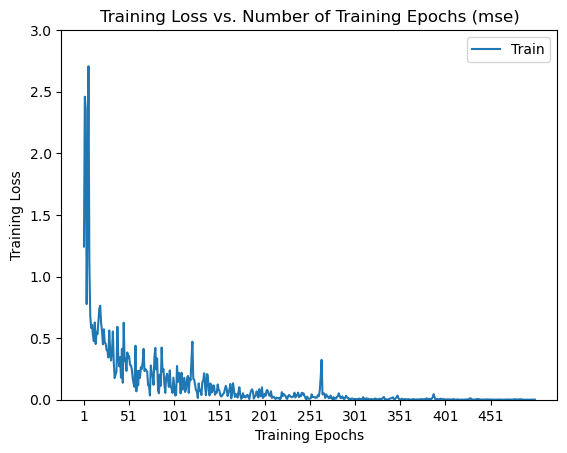

iteration 0: loss 1.089840
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
iteration 10: loss 1.279227
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
iteration 20: loss 0.742986
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
dCdb2.shape: (1, 3) (1, 1500)
iteration 30: los

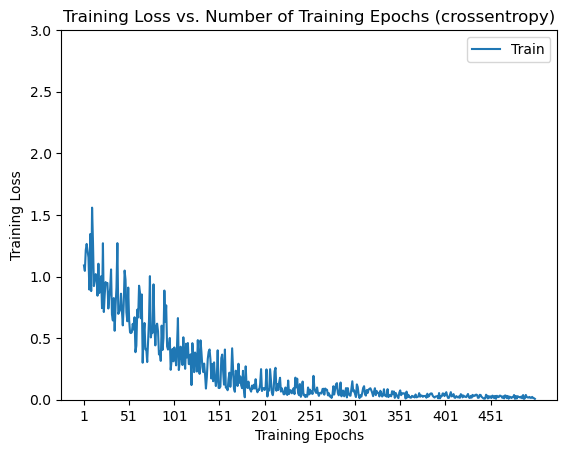

In [4]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# set a fixed seed for reproducability
np.random.seed(0)

nn_img_size = 32
num_classes = 3
learning_rate = 0.0001
num_epochs = 500
batch_size = 4

loss_mode = 'mse'

loss_train_hist = []

##################################################
## Please implement a two layer neural network  ##
##################################################


def relu(x):
    """ReLU activation function"""
    return np.maximum(x, 0)


def relu_derivative(output):
    """derivative of the ReLU activation function"""
    deriv = np.zeros_like(output)
    deriv[output > 0] = 1
    return deriv


def softmax(z):
    """softmax function to transform values to probabilities"""
    z = z - z.max(axis=1, keepdims=True)
    z = np.exp(z)
    sum_z = z.sum(axis=1, keepdims=True)
    return z / sum_z


def loss_mse(activation, y_batch):
    """mean squared loss function"""
    # use MSE error as loss function
    # Hint: the computed error needs to get normalized over the number of samples
    loss = ((activation - y_batch)**2).sum()
    mse = 1.0 / activation.shape[0] * loss
    return mse


def loss_crossentropy(activation, y_batch):
    """cross entropy loss function"""
    batch_size = y_batch.shape[0]
    eps = 1e-12
    activation = np.clip(activation, eps, 1.0)
    loss = (-y_batch * np.log(activation)).sum() / batch_size
    return loss


def loss_deriv_mse(activation, y_batch):
    """derivative of the mean squared loss function"""
    dCda2 = (1 / activation.shape[0]) * (activation - y_batch)
    return dCda2


def loss_deriv_crossentropy(activation, y_batch):
    """derivative of the mean cross entropy loss function, that includes the derivate of the softmax
       for further explanations see here: https://deepnotes.io/softmax-crossentropy
    """
    batch_size = y_batch.shape[0]
    dCda2 = activation
    dCda2[range(batch_size), np.argmax(y_batch, axis=1)] -= 1
    dCda2 /= batch_size
    return dCda2


def setup_train():
    """train function"""
    # load and resize train images in three categories
    # cars = 0, flowers = 1, faces = 2 ( true_ids )
    train_images_cars = glob.glob('./images/db/train/cars/*.jpg')
    train_images_flowers = glob.glob('./images/db/train/flowers/*.jpg')
    train_images_faces = glob.glob('./images/db/train/faces/*.jpg')
    if not train_images_cars or not train_images_flowers or not train_images_faces:
        raise ValueError(
            'No image found! Please make sure the images are in the correct location.'
        )

    train_images = [train_images_cars, train_images_flowers, train_images_faces]
    num_rows = len(train_images_cars) + len(train_images_flowers) + len(
        train_images_faces)
    X_train = np.zeros((num_rows, nn_img_size * nn_img_size))
    y_train = np.zeros((num_rows, num_classes))

    counter = 0
    for (label, fnames) in enumerate(train_images):
        for fname in fnames:
            print(label, fname)
            img = cv2.imread(fname, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (nn_img_size, nn_img_size),
                             interpolation=cv2.INTER_AREA)

            # print(label, fname, img.shape)

            # fill matrices X_train - each row is an image vector
            # y_train - one-hot encoded, put only a 1 where the label is correct for the row in X_train
            y_train[counter, label] = 1
            X_train[counter] = img.flatten().astype(np.float32)

            counter += 1

    # print(y_train)
    return X_train, y_train


def forward(X_batch, y_batch, W1, W2, b1, b2, loss_mode=loss_mode):
    """forward pass in the neural network"""

    # Hidden layer
    Z1 = X_batch.dot(W1) + b1
    a1 = relu(Z1)

    # Output layer
    Z2 = a1.dot(W2) + b2

    # Output activation
    if loss_mode == 'crossentropy':
        a2 = softmax(Z2)
        loss = loss_crossentropy(a2, y_batch)

    elif loss_mode == 'mse':
        a2 = Z2
        loss = loss_mse(a2, y_batch)

    else:
        raise ValueError("Invalid loss mode. Choose 'mse' or 'crossentropy'.")

    # return Z1 instead of m1
    return loss, a2, a1, Z1

def backward(a2, a1, X_batch, y_batch, W2, Z1, loss_mode=loss_mode):

    if loss_mode == 'mse':
        dL = loss_deriv_mse(a2, y_batch)
    else:
        dL = loss_deriv_crossentropy(a2, y_batch)

    dCdW2 = a1.T.dot(dL)
    dCdb2 = dL.sum(axis=0, keepdims=True)

    dCda1 = dL.dot(W2.T)

    # compute derivative here
    dCdm1 = dCda1 * relu_derivative(Z1)

    dCdW1 = X_batch.T.dot(dCdm1)
    dCdb1 = dCdm1.sum(axis=0, keepdims=True)

    return dCdW1, dCdW2, dCdb1, dCdb2


def train(X_train, y_train, loss_mode=loss_mode):
    """ train procedure """
    # for simplicity of this execise you don't need to find useful hyperparameter
    # I've done this for you already and every test image should work for the
    # given very small trainings database and the following parameters.
    h = 1500
    std = 0.001
    # YOUR CODE HERE
    # initialize W1, W2, b1, b2 randomly
    # Note: W1, W2 should be scaled by variable std

    W1 = std * np.random.randn(X_train.shape[1], h)
    W2 = std * np.random.randn(h, num_classes)
    b1 = np.zeros((1, h))
    b2 = np.zeros((1, num_classes))

    # run for num_epochs
    for i in range(num_epochs):

        X_batch = None
        y_batch = None

        # use only a batch of batch_size of the training images in each run
        # sample the batch images randomly from the training set
        # YOUR CODE HERE

        batch = np.random.choice(X_train.shape[0], batch_size, replace=False)
        X_batch = X_train[batch]
        y_batch = y_train[batch]

        # forward pass for two-layer neural network using ReLU as activation function

        loss, a2, a1, m1 = forward(X_batch, y_batch, W1, W2, b1, b2, loss_mode=loss_mode)

        # add loss to loss_train_hist for plotting

        loss_train_hist.append(loss)

        if i % 10 == 0:
            print("iteration %d: loss %f" % (i, loss))

        # backward pass
    
        dCdW1, dCdW2, dCdb1, dCdb2 = backward(a2, a1, X_batch, y_batch, W2, m1, loss_mode)

        print("dCdb2.shape:", dCdb2.shape, dCdb1.shape)

        # depending on the derivatives of W1, and W2 regaring the cost/loss
        # we need to adapt the values in the negative direction of the
        # gradient decreasing towards the minimum
        # we weight the gradient by a learning rate
        # YOUR CODE HERE

        W1 -= learning_rate * dCdW1
        W2 -= learning_rate * dCdW2
        b1 -= learning_rate * dCdb1
        b2 -= learning_rate * dCdb2

    return W1, W2, b1, b2


X_train, y_train = setup_train()

loss_modes = ['mse', 'crossentropy']  

for loss_mode in loss_modes:

    loss_train_hist = [] 

    W1, W2, b1, b2 = train(X_train, y_train, loss_mode=loss_mode)

    test_images = []
    test_images.append((cv2.imread('./images/db/test/flower2.jpg', cv2.IMREAD_GRAYSCALE), 1))
    test_images.append((cv2.imread('./images/db/test/car.jpg', cv2.IMREAD_GRAYSCALE), 0))
    test_images.append((cv2.imread('./images/db/test/face.jpg', cv2.IMREAD_GRAYSCALE), 2))

    for ti in test_images:
        resized_ti = cv2.resize(ti[0], (nn_img_size, nn_img_size), interpolation=cv2.INTER_AREA)
        x_test = resized_ti.reshape(1, -1)
        _, a2_test, _, _ = forward(x_test, np.zeros((1, num_classes)), W1, W2, b1, b2, loss_mode=loss_mode)
        print(f"Test output - values: {a2_test} \t pred_id: {np.argmax(a2_test)} \t true_id: {ti[1]}")

    plt.figure()  
    plt.title(f"Training Loss vs. Number of Training Epochs ({loss_mode})")
    plt.xlabel("Training Epochs")
    plt.ylabel("Training Loss")
    plt.plot(range(1, num_epochs + 1), loss_train_hist, label="Train")
    plt.ylim((0, 3.))
    plt.xticks(np.arange(1, num_epochs + 1, 50.0))
    plt.legend()
    plt.savefig(f"two_layer_nn_train_{loss_mode}.png")
    plt.show()



===== Training MyNeuralNetwork =====
Epoch 0/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 469
Training Batch:  300 of 469
Training Batch:  400 of 469
----------
Training Loss: 0.5249 Acc: 0.8068

Test Batch:    0 of 79
Test Batch:   10 of 79
Test Batch:   20 of 79
Test Batch:   30 of 79
Test Batch:   40 of 79
Test Batch:   50 of 79
Test Batch:   60 of 79
Test Batch:   70 of 79
----------
Test Loss: 0.3230 Acc: 0.8837

Epoch 1/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 469
Training Batch:  300 of 469
Training Batch:  400 of 469
----------
Training Loss: 0.3139 Acc: 0.8857

Test Batch:    0 of 79
Test Batch:   10 of 79
Test Batch:   20 of 79
Test Batch:   30 of 79
Test Batch:   40 of 79
Test Batch:   50 of 79
Test Batch:   60 of 79
Test Batch:   70 of 79
----------
Test Loss: 0.2658 Acc: 0.9013

Epoch 2/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  20

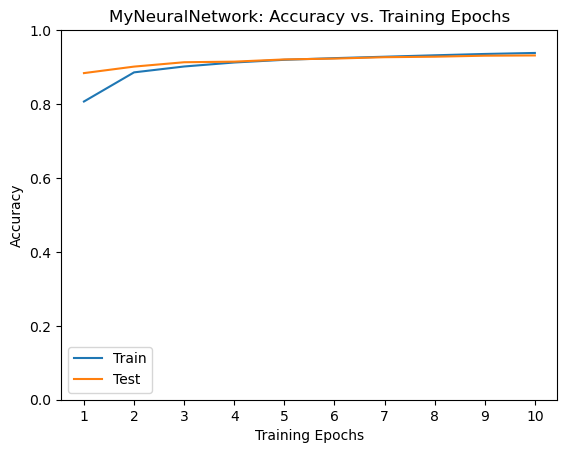

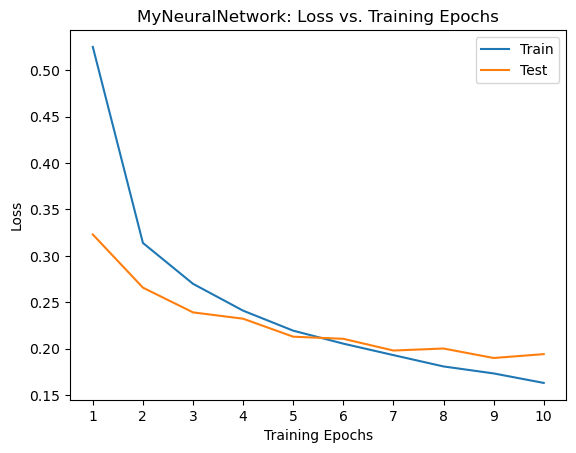

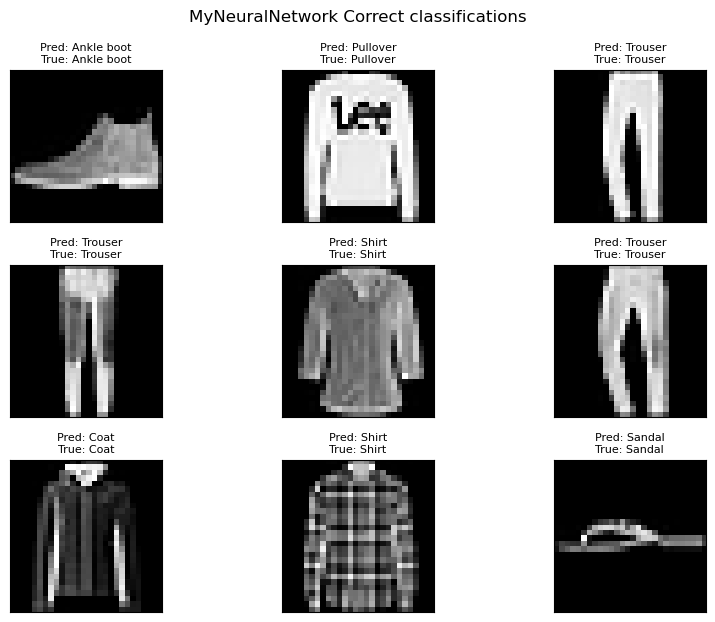

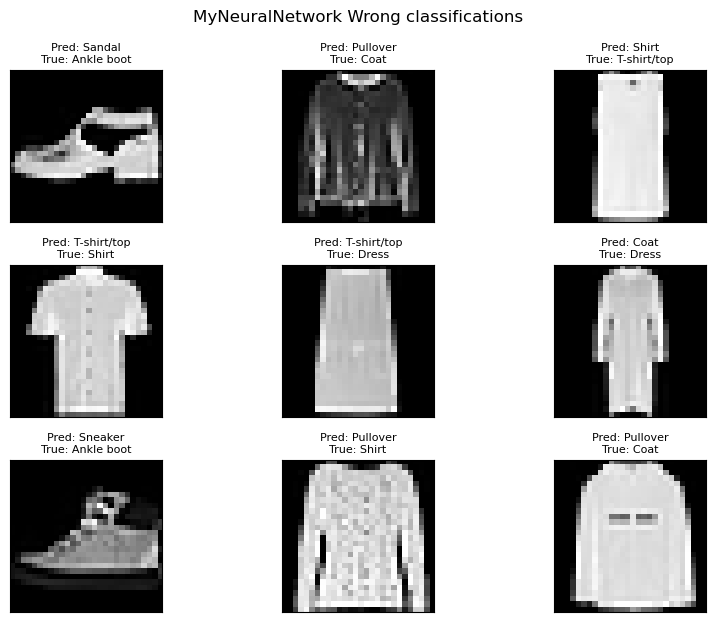


===== Training LeNetFashion =====
Epoch 0/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 469
Training Batch:  300 of 469
Training Batch:  400 of 469
----------
Training Loss: 0.7111 Acc: 0.7390

Test Batch:    0 of 79
Test Batch:   10 of 79
Test Batch:   20 of 79
Test Batch:   30 of 79
Test Batch:   40 of 79
Test Batch:   50 of 79
Test Batch:   60 of 79
Test Batch:   70 of 79
----------
Test Loss: 0.5261 Acc: 0.7939

Epoch 1/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 469
Training Batch:  300 of 469
Training Batch:  400 of 469
----------
Training Loss: 0.4441 Acc: 0.8357

Test Batch:    0 of 79
Test Batch:   10 of 79
Test Batch:   20 of 79
Test Batch:   30 of 79
Test Batch:   40 of 79
Test Batch:   50 of 79
Test Batch:   60 of 79
Test Batch:   70 of 79
----------
Test Loss: 0.4293 Acc: 0.8429

Epoch 2/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 o

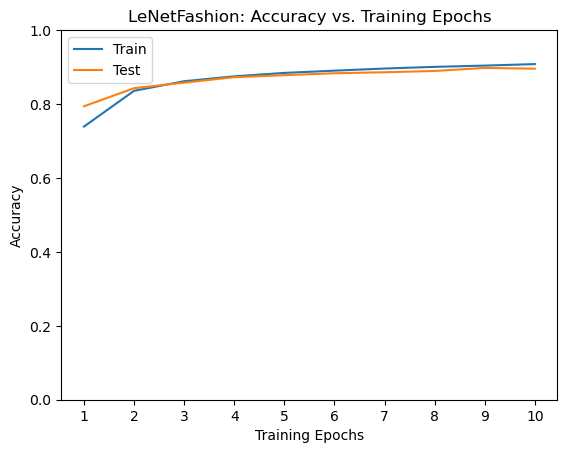

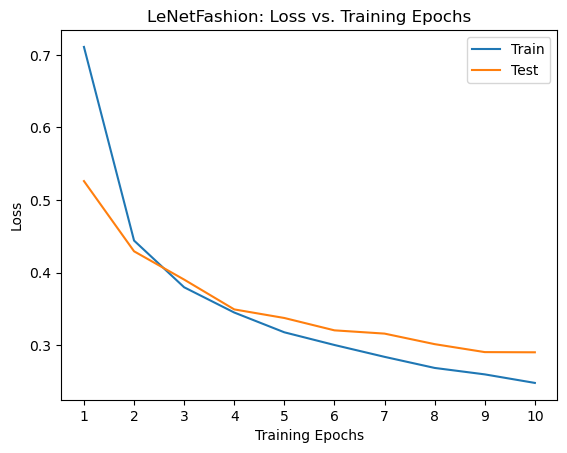

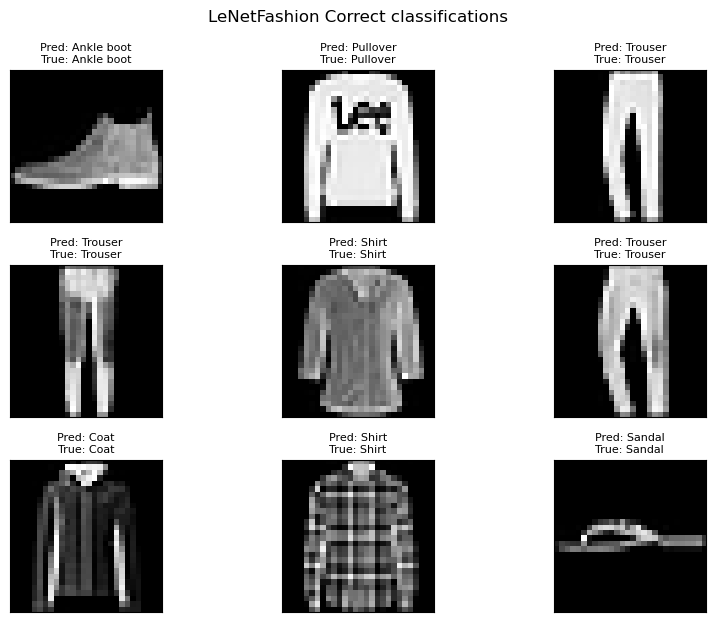

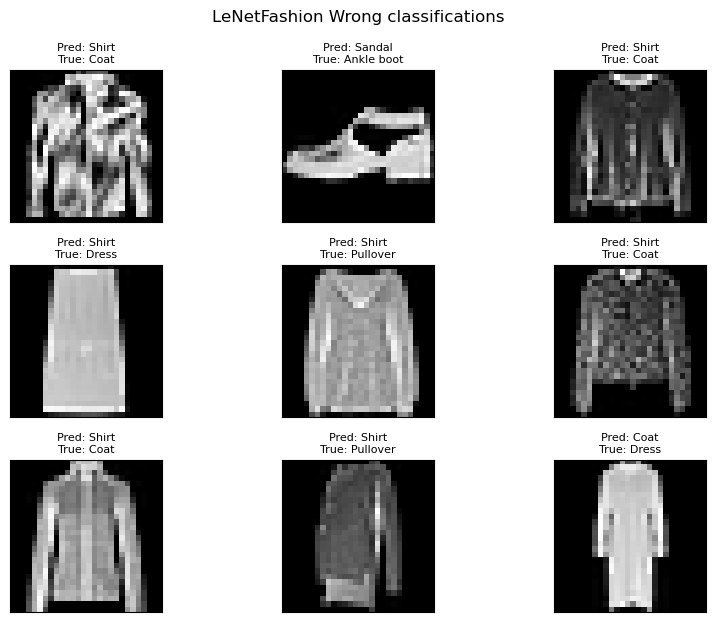


===== Training VGGFashion =====
Epoch 0/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 469
Training Batch:  300 of 469
Training Batch:  400 of 469
----------
Training Loss: 0.6524 Acc: 0.7565

Test Batch:    0 of 79
Test Batch:   10 of 79
Test Batch:   20 of 79
Test Batch:   30 of 79
Test Batch:   40 of 79
Test Batch:   50 of 79
Test Batch:   60 of 79
Test Batch:   70 of 79
----------
Test Loss: 0.3997 Acc: 0.8499

Epoch 1/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 469
Training Batch:  300 of 469
Training Batch:  400 of 469
----------
Training Loss: 0.3654 Acc: 0.8673

Test Batch:    0 of 79
Test Batch:   10 of 79
Test Batch:   20 of 79
Test Batch:   30 of 79
Test Batch:   40 of 79
Test Batch:   50 of 79
Test Batch:   60 of 79
Test Batch:   70 of 79
----------
Test Loss: 0.3220 Acc: 0.8790

Epoch 2/9
----------
Training Batch:    0 of 469
Training Batch:  100 of 469
Training Batch:  200 of 

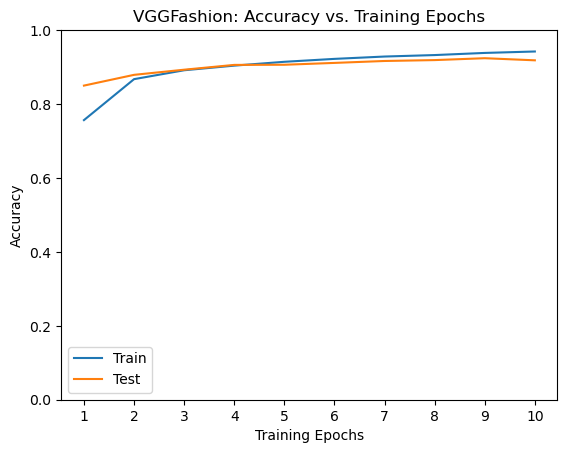

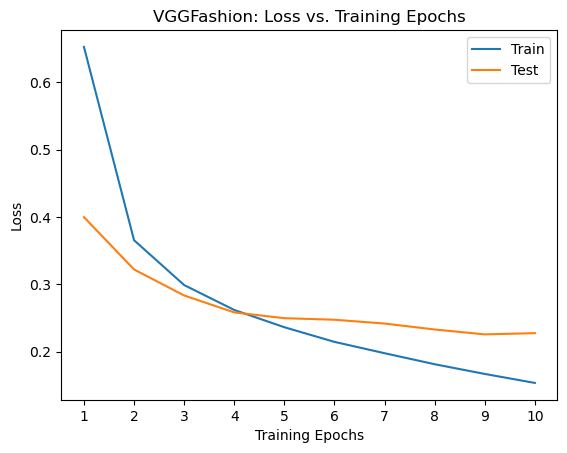

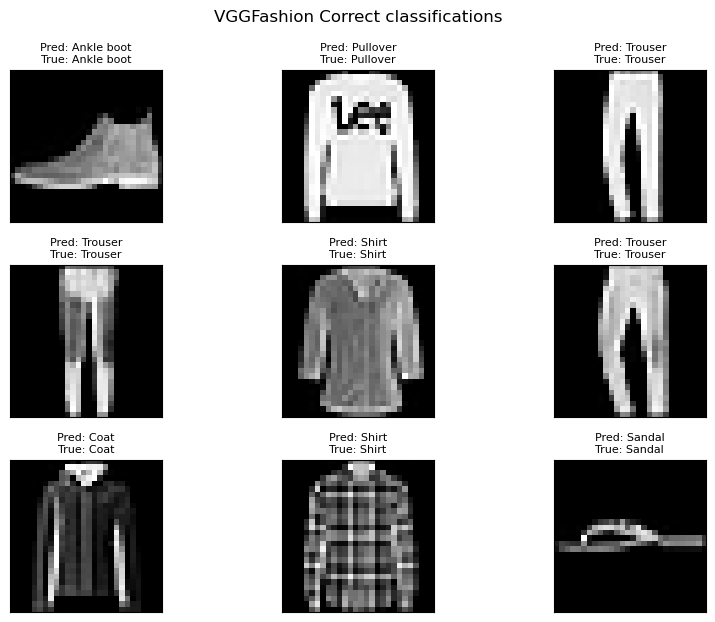

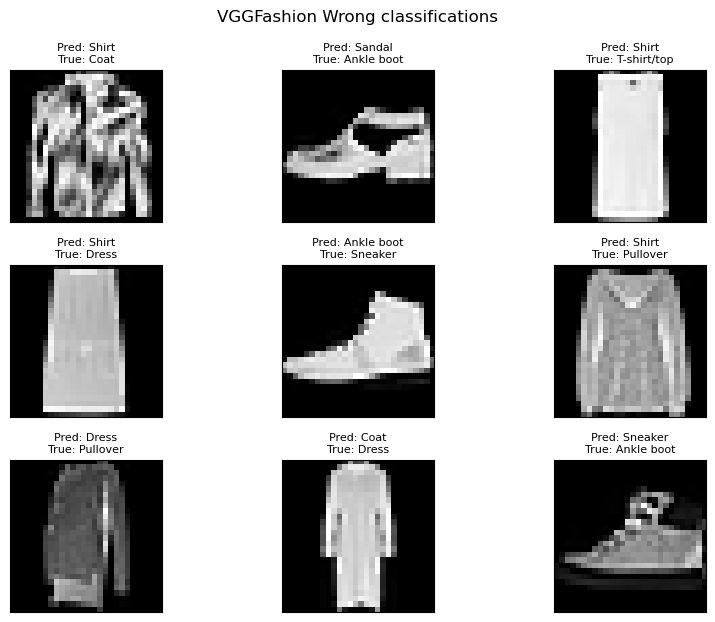


Training complete in 8m 25s
MyNeuralNetwork: best test acc = 0.9315
LeNetFashion: best test acc = 0.8977
VGGFashion: best test acc = 0.9240
Overall best model: MyNeuralNetwork (acc 0.9315)


<All keys matched successfully>

In [10]:
# source code inspired by
# https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html#model-training-and-validation-code

import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

CATEGORIES = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

class MyNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def name(self):
        return "MyNeuralNetwork"

class LeNetFashion(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def name(self):
        return "LeNetFashion"

class VGGFashion(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def name(self):
        return "VGGFashion"


def training(model, data_loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    running_corrects = 0

    for batch_idx, (inputs, labels) in enumerate(data_loader):

        optimizer.zero_grad()

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        if batch_idx % 100 == 0:
            print(f'Training Batch: {batch_idx:4} of {len(data_loader)}')

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_acc = running_corrects.float() / len(data_loader.dataset)

    print('-' * 10)
    print(f'Training Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}\n')

    return epoch_loss, epoch_acc


def test(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():

        for batch_idx, (inputs, labels) in enumerate(data_loader):

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if batch_idx % 10 == 0:
                print(f'Test Batch: {batch_idx:4} of {len(data_loader)}')

        epoch_loss = running_loss / len(data_loader.dataset)
        epoch_acc = running_corrects.float() / len(data_loader.dataset)

    print('-' * 10)
    print(f'Test Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}\n')

    return epoch_loss, epoch_acc


def plot(train_history, test_history, metric, num_epochs, model_name):
    """Plot one metric (accuracy or loss) for ONE model. Called once per
    network so histories of different architectures never get mixed."""
    plt.figure()
    plt.title(f"{model_name}: {metric.capitalize()} vs. Training Epochs")
    plt.xlabel("Training Epochs")
    plt.ylabel(metric.capitalize())
    plt.plot(range(1, num_epochs + 1), train_history, label="Train")
    plt.plot(range(1, num_epochs + 1), test_history, label="Test")
    if metric == "accuracy":
        plt.ylim((0, 1.))
    step = max(1, num_epochs // 10)
    plt.xticks(np.arange(1, num_epochs + 1, step))
    plt.legend()
    plt.savefig(f"{model_name}_{metric}.png")
    plt.show()
    plt.close()


def plot_examples(model, data_loader, device, categories,model_name, num_examples=9):  

    """Show separate figures for correctly and incorrectly classified
    examples, each labelled with both predicted and true class
    (matches Abbildung 3 (c) and (d))."""

    model.eval()
    correct_examples = []
    wrong_examples = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            for i in range(inputs.size(0)):
                sample = (inputs[i].cpu(), labels[i].item(), preds[i].item())
                if preds[i] == labels[i] and len(correct_examples) < num_examples:
                    correct_examples.append(sample)
                elif preds[i] != labels[i] and len(wrong_examples) < num_examples:
                    wrong_examples.append(sample)

            if len(correct_examples) >= num_examples and len(wrong_examples) >= num_examples:
                break

    def _plot(examples, title, filename):
        plt.figure(figsize=(9, 6))
        for i, (img, true_label, pred_label) in enumerate(examples):
            plt.subplot(3, 3, i + 1)
            plt.imshow(img[0], cmap='gray', interpolation='none')
            plt.title(f"Pred: {categories[pred_label]}\nTrue: {categories[true_label]}",
                      fontsize=8)
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.suptitle(title, y=1.03)
        plt.savefig(filename)
        plt.show()
        plt.close()

    _plot(correct_examples,
        f"{model_name} Correct classifications",
        f"{model_name}_correct.png")

    _plot(wrong_examples,
        f"{model_name} Wrong classifications",
        f"{model_name}_wrong.png")


device = torch.device(
    "cuda:0" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# set seed for reproducability
torch.manual_seed(0)

# hyperparameter
# TODO: find good hyperparameters
batch_size = 128
num_epochs = 10
learning_rate = 0.001

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# load train and test data
root = './data'
train_set = datasets.FashionMNIST(root=root,
                                   train=True,
                                   transform=transform,
                                   download=True)
test_set = datasets.FashionMNIST(root=root,
                                  train=False,
                                  transform=transform,
                                  download=True)

# Set to True for a quick sanity-check run on a small subset (seconds instead
# of minutes per epoch). Set to False for the real run with the full dataset.
QUICK_TEST = False
if QUICK_TEST:
    from torch.utils.data import Subset
    train_set = Subset(train_set, range(2000))
    test_set = Subset(test_set, range(1000))

loader_params = {
    'batch_size': batch_size,
    'num_workers': 0  # 0 is safest in Jupyter notebooks (esp. on macOS, where
                      # multiprocessing uses 'spawn' and worker serialization
                      # of the dataset often fails outside a plain .py script)
}

train_loader = DataLoader(dataset=train_set, shuffle=True, **loader_params)
test_loader = DataLoader(dataset=test_set, shuffle=False, **loader_params)

criterion = nn.CrossEntropyLoss()

# model setup: build all three architectures
networks = {
    "MyNeuralNetwork": MyNeuralNetwork().to(device),
    "LeNetFashion": LeNetFashion().to(device),
    "VGGFashion": VGGFashion().to(device),
}

results = {}
overall_best_acc = 0.0
overall_best_model_name = None
overall_best_model_wts = None

since = time.time()

for name, net in networks.items():

    print(f"\n===== Training {name} =====")
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    # IMPORTANT: reset per-model so histories of different
    # architectures are never concatenated together
    train_acc_history = []
    test_acc_history = []
    train_loss_history = []
    test_loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):

        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # train
        training_loss, training_acc = training(net, train_loader, optimizer, criterion, device)
        train_loss_history.append(training_loss)
        train_acc_history.append(training_acc)

        # test
        test_loss, test_acc = test(net, test_loader, criterion, device)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)

        # best epoch for this model
        if test_acc > best_acc:
            best_acc = test_acc

        # best model overall, across all architectures
        if test_acc > overall_best_acc:
            overall_best_acc = test_acc
            overall_best_model_name = name
            overall_best_model_wts = copy.deepcopy(net.state_dict())

    # convert accuracy tensors -> numpy for plotting
    train_acc_history = [h.cpu().numpy() for h in train_acc_history]
    test_acc_history = [h.cpu().numpy() for h in test_acc_history]

    results[name] = {
        "best_acc": best_acc.item() if torch.is_tensor(best_acc) else best_acc
    }

    # plot this model's curves immediately, before moving to the next model
    plot(train_acc_history, test_acc_history, 'accuracy', num_epochs, name)
    plot(train_loss_history, test_loss_history, 'loss', num_epochs, name)

    plot_examples(net, test_loader, device, CATEGORIES, name)

time_elapsed = time.time() - since
print(f'\nTraining complete in {(time_elapsed // 60):.0f}m {(time_elapsed % 60):.0f}s')
for name, res in results.items():
    print(f'{name}: best test acc = {res["best_acc"]:.4f}')
print(f'Overall best model: {overall_best_model_name} (acc {overall_best_acc:.4f})')

best_net = networks[overall_best_model_name]
best_net.load_state_dict(overall_best_model_wts)
